# Оценка LLM-пайплайна на ручной разметке 1000 новостей

Этот notebook проверяет именно LLM-контур проекта:
- текущий `LLMClient`;
- текущий `CLASSIFICATION_SYSTEM_PROMPT`;
- текущий `build_classification_user_prompt`;
- текущий `normalize_classification_response`;
- текущую production-логику `is_relevant`.

В отличие от BERT baseline, LLM-пайплайн умеет явно возвращать пустой список факторов,
то есть `not_relevant` является естественным результатом классификации.

Ответы и нормализованные предсказания кэшируются в `analysis_outputs/`.

In [1]:
from __future__ import annotations

import hashlib
import json
import math
import os
import re
import sys
import time
from dataclasses import replace
from pathlib import Path
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    hamming_loss,
    matthews_corrcoef,
    mean_absolute_error,
    mean_squared_error,
    precision_recall_fscore_support,
    r2_score,
)
from sklearn.preprocessing import MultiLabelBinarizer

ROOT = Path.cwd()
if not (ROOT / "manage.py").exists():
    ROOT = Path(r"C:\Users\whynot\VSCodeProjects\news-zero-shot")
sys.path.insert(0, str(ROOT))

DATASET_PATH = ROOT / "interfax_news_manual_factor_dataset_1000.csv"
OUTPUT_DIR = ROOT / "analysis_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# Батчинг поддерживается самим prompt builder и сервисным кодом.
# При больших батчах локальная Gemma иногда пропускает news_id, поэтому используем 5 и fallback на одиночные вызовы.
EVAL_LLM_BATCH_SIZE = 5
EVAL_LLM_TIMEOUT_SECONDS = 240
EVAL_LLM_MAX_TOKENS = 4096
DEFAULT_LLM_RELEVANCE_THRESHOLD = 0.30
DEFAULT_LLM_SIGNAL_THRESHOLD = 0.20

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 140)
pd.set_option("display.max_colwidth", 160)

print(f"project_root={ROOT}")
print(f"dataset={DATASET_PATH}")
print(f"output_dir={OUTPUT_DIR}")

project_root=C:\Users\whynot\VSCodeProjects\news-zero-shot
dataset=C:\Users\whynot\VSCodeProjects\news-zero-shot\interfax_news_manual_factor_dataset_1000.csv
output_dir=C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs


## 1. Загрузка ручной разметки и факторного каталога

In [2]:
from analyzer.constants import FACTOR_CATALOG_VERSION, LLM_CLASSIFICATION_PROMPT_VERSION, normalize_factor_key
from analyzer.factors import FACTOR_CONFIG
from analyzer.llm_client import LLMClient, LLMError, get_llm_settings
from analyzer.llm_prompts import CLASSIFICATION_SYSTEM_PROMPT, build_classification_user_prompt
from analyzer.llm_services import (
    factor_catalog_payload,
    news_payload,
    normalize_classification_response,
)

COL = {
    "row_id": "Номер строки в датасете 1000",
    "batch": "Партия разметки",
    "source_row_id": "Номер новости в исходной выборке 1000",
    "section": "Раздел новости",
    "section_code": "Код раздела в исходном файле",
    "month": "Месяц публикации",
    "published_at": "Дата и время публикации",
    "title": "Заголовок новости",
    "description": "Описание новости",
    "first_paragraph": "Первый абзац новости",
    "full_text": "Полный текст новости",
    "url": "Ссылка на новость",
    "manual_applicable": "Фактор применим",
    "manual_factor": "Ключ основного фактора",
    "manual_factor_name": "Название основного фактора",
    "manual_factor_block": "Блок основного фактора",
    "manual_weight": "Вес основного фактора",
    "manual_additional_factors": "Дополнительные факторы",
    "manual_signal": "Метка сигнала",
    "manual_sentiment": "Числовая тональность",
    "manual_relevance": "Релевантность фактора от 0 до 1",
    "manual_pressure": "Давление риска от 0 до 1",
    "manual_confidence": "Уверенность разметчика от 0 до 1",
    "manual_evidence": "Фраза доказательство из новости",
    "needs_review": "Нужна повторная экспертная проверка",
    "annotation_status": "Статус ручной разметки",
    "catalog_version": "Версия факторного каталога",
}

raw_df = pd.read_csv(DATASET_PATH)
missing_columns = [name for name in COL.values() if name not in raw_df.columns]
if missing_columns:
    raise ValueError(f"В CSV не найдены ожидаемые колонки: {missing_columns}")

factor_df = pd.DataFrame(FACTOR_CONFIG)
factor_keys = factor_df["key"].tolist()
factor_weights = dict(zip(factor_df["key"], factor_df["weight"]))

Factor = SimpleNamespace
News = SimpleNamespace
factors = [Factor(id=i + 1, **item) for i, item in enumerate(FACTOR_CONFIG)]
factor_by_key = {factor.key: factor for factor in factors}
factor_catalog = factor_catalog_payload(factors)

def yes_no(value) -> bool:
    return str(value).strip().lower() in {"да", "yes", "true", "1", "y"}

def clean_text(value) -> str:
    if pd.isna(value):
        return ""
    return re.sub(r"\s+", " ", str(value)).strip()

def parse_additional_factors(value) -> list[str]:
    if pd.isna(value) or not str(value).strip():
        return []
    parsed = []
    for part in re.split(r"[;,\n|]+", str(value)):
        key = normalize_factor_key(part.strip())
        if key and key in factor_keys and key not in parsed:
            parsed.append(key)
    return parsed

def normalize_signal(value) -> str:
    label = str(value or "neutral").strip().lower()
    return label if label in {"positive", "negative", "neutral"} else "neutral"

df = raw_df.copy()
df["dataset_row_id"] = pd.to_numeric(df[COL["row_id"]], errors="raise").astype(int)
df["published_at"] = pd.to_datetime(df[COL["published_at"]], errors="coerce")
df["published_date"] = df["published_at"].dt.date
df["manual_applicable_bool"] = df[COL["manual_applicable"]].map(yes_no)
df["manual_primary_factor"] = df[COL["manual_factor"]].map(lambda value: normalize_factor_key(str(value).strip()) if pd.notna(value) else None)
df["manual_primary_factor"] = df["manual_primary_factor"].fillna("not_relevant")
df["manual_signal_norm"] = df[COL["manual_signal"]].map(normalize_signal)
df["manual_sentiment_num"] = pd.to_numeric(df[COL["manual_sentiment"]], errors="coerce").fillna(0.0)
df["manual_relevance_num"] = pd.to_numeric(df[COL["manual_relevance"]], errors="coerce").fillna(0.0)
df["manual_pressure_num"] = pd.to_numeric(df[COL["manual_pressure"]], errors="coerce").fillna(0.0)
df["manual_confidence_num"] = pd.to_numeric(df[COL["manual_confidence"]], errors="coerce")
df["needs_review_bool"] = df[COL["needs_review"]].map(yes_no)
df["additional_factor_list"] = df[COL["manual_additional_factors"]].map(parse_additional_factors)

def manual_factor_set(row) -> list[str]:
    keys = []
    primary = row["manual_primary_factor"]
    if row["manual_applicable_bool"] and primary in factor_keys:
        keys.append(primary)
    for key in row["additional_factor_list"]:
        if key not in keys:
            keys.append(key)
    return keys

df["manual_factor_set"] = df.apply(manual_factor_set, axis=1)
df["manual_factor_count"] = df["manual_factor_set"].map(len)
df["eval_text"] = df[COL["full_text"]].map(clean_text)
fallback_text = (
    df[COL["title"]].map(clean_text)
    + ". "
    + df[COL["description"]].map(clean_text)
    + ". "
    + df[COL["first_paragraph"]].map(clean_text)
).str.strip(". ")
df["eval_text"] = df["eval_text"].where(df["eval_text"].str.len() > 0, fallback_text)
df["eval_text_chars"] = df["eval_text"].str.len()

display(
    pd.DataFrame(
        [
            ("rows", len(df)),
            ("manual_applicable_yes", int(df["manual_applicable_bool"].sum())),
            ("manual_not_relevant", int((~df["manual_applicable_bool"]).sum())),
            ("manual_primary_factor_count", int(df.loc[df["manual_applicable_bool"], "manual_primary_factor"].nunique())),
            ("rows_with_additional_factors", int(df["additional_factor_list"].map(bool).sum())),
            ("rows_needing_review", int(df["needs_review_bool"].sum())),
            ("mean_text_chars", round(float(df["eval_text_chars"].mean()), 1)),
        ],
        columns=["metric", "value"],
    )
)
display(df[["dataset_row_id", COL["title"], "manual_applicable_bool", "manual_primary_factor", "manual_signal_norm", "manual_relevance_num", "manual_pressure_num"]].head())

,metric,value
0,rows,1000.0
1,manual_applicable_yes,725.0
2,manual_not_relevant,275.0
3,manual_primary_factor_count,20.0
4,rows_with_additional_factors,182.0
5,rows_needing_review,99.0
6,mean_text_chars,1565.0


,dataset_row_id,Заголовок новости,manual_applicable_bool,manual_primary_factor,manual_signal_norm,manual_relevance_num,manual_pressure_num
0,1,Путин поручил разработать план подъема двух затонувших в Черном море танкеров,True,air_pollution,negative,0.9,0.85
1,2,Мозамбик пригласил российские компании добывать газ в стране,False,not_relevant,neutral,0.0,0.00
2,3,Старт вечерней сессии на срочном рынке Мосбиржи задерживается,False,not_relevant,neutral,0.0,0.00
3,4,Аэропорты Волгограда и Краснодара приостановили работу,False,not_relevant,neutral,0.1,0.05
4,5,Шторм в Великобритании и Ирландии привел к сбоям в работе транспортной системы,False,not_relevant,neutral,0.1,0.05


## 2. LLM-инференс с кэшем и fallback

In [3]:
llm_settings_base = get_llm_settings()
llm_settings = replace(
    llm_settings_base,
    timeout_seconds=max(float(llm_settings_base.timeout_seconds), EVAL_LLM_TIMEOUT_SECONDS),
    max_tokens=max(int(llm_settings_base.max_tokens), EVAL_LLM_MAX_TOKENS),
    batch_news_size=EVAL_LLM_BATCH_SIZE,
)
client = LLMClient(llm_settings)
print(llm_settings)

text_hash = hashlib.sha256("\n".join(df["eval_text"].tolist()).encode("utf-8")).hexdigest()[:12]
prompt_hash = hashlib.sha256((CLASSIFICATION_SYSTEM_PROMPT + json.dumps(factor_catalog, ensure_ascii=False)).encode("utf-8")).hexdigest()[:12]
cache_stem = f"manual_dataset_llm_predictions_{llm_settings.model.replace(':', '-')}_{llm_settings.classification_prompt_version}_{text_hash}_{prompt_hash}"
final_predictions_path = OUTPUT_DIR / f"{cache_stem}.csv"
partial_predictions_path = OUTPUT_DIR / f"{cache_stem}.partial.csv"
errors_path = OUTPUT_DIR / f"{cache_stem}.errors.csv"
raw_jsonl_path = OUTPUT_DIR / f"{cache_stem}.raw.jsonl"
expected_prediction_rows = len(df) * len(factor_keys)

def make_news(row) -> News:
    published_at = row["published_at"]
    if pd.isna(published_at):
        published_at = pd.Timestamp("1970-01-01T12:00:00+03:00")
    return News(
        id=int(row["dataset_row_id"]),
        published_at=published_at.to_pydatetime(),
        title=clean_text(row[COL["title"]]),
        summary=clean_text(row[COL["description"]]),
        text=clean_text(row["eval_text"]),
        url=clean_text(row[COL["url"]]),
    )

news_by_id = {int(row["dataset_row_id"]): make_news(row) for _, row in df.iterrows()}

def llm_is_relevant(factor_payload: dict) -> bool:
    return (
        float(factor_payload["relevance"]) >= DEFAULT_LLM_RELEVANCE_THRESHOLD
        and (
            abs(float(factor_payload["sentiment"])) >= DEFAULT_LLM_SIGNAL_THRESHOLD
            or float(factor_payload["pressure"]) >= DEFAULT_LLM_SIGNAL_THRESHOLD
            or factor_payload["label"] != "neutral"
        )
    )

def normalized_rows_from_response(response: dict, batch_news: list[News], raw_text: str, call_status: str) -> tuple[list[dict], list[str]]:
    normalized_items, warnings = normalize_classification_response(response, batch_news, factors)
    rows = []
    for item_payload in normalized_items:
        news_item = item_payload["news_item"]
        for factor_payload in item_payload["factors"]:
            sentiment = float(factor_payload["sentiment"])
            positive_probability = (sentiment + 1.0) / 2.0
            negative_probability = 1.0 - positive_probability
            rows.append(
                {
                    "dataset_row_id": int(news_item.id),
                    "factor_key": factor_payload["factor_id"],
                    "factor_name": factor_by_key[factor_payload["factor_id"]].name,
                    "relevance": float(factor_payload["relevance"]),
                    "sentiment_score": sentiment,
                    "pressure": float(factor_payload["pressure"]),
                    "confidence": float(factor_payload["confidence"]),
                    "sentiment_label": factor_payload["label"],
                    "positive_probability": positive_probability,
                    "negative_probability": negative_probability,
                    "is_relevant": llm_is_relevant(factor_payload),
                    "evidence": factor_payload["evidence"] if factor_payload["raw"] else "",
                    "reason": factor_payload["reason"] if factor_payload["raw"] else "",
                    "raw_factor_returned": bool(factor_payload["raw"]),
                    "call_status": call_status,
                    "raw_text_chars": len(raw_text or ""),
                }
            )
    return rows, warnings

def append_rows(path: Path, rows: list[dict]) -> None:
    if not rows:
        return
    frame = pd.DataFrame(rows)
    frame.to_csv(path, mode="a", header=not path.exists(), index=False, encoding="utf-8")

def append_jsonl(path: Path, payload: dict) -> None:
    with path.open("a", encoding="utf-8") as handle:
        handle.write(json.dumps(payload, ensure_ascii=False) + "\n")

def classify_batch(batch_ids: list[int], status_prefix: str = "batch") -> tuple[list[dict], list[dict]]:
    batch_news = [news_by_id[item_id] for item_id in batch_ids]
    started = time.time()
    prompt = build_classification_user_prompt(news_payload(batch_news), factor_catalog)
    try:
        response, raw_text = client.complete_json(CLASSIFICATION_SYSTEM_PROMPT, prompt)
        rows, warnings = normalized_rows_from_response(response, batch_news, raw_text, status_prefix)
        missing_ids = sorted(set(batch_ids) - set(pd.DataFrame(rows)["dataset_row_id"].unique())) if rows else batch_ids
        for warning in warnings:
            match = re.search(r"news_id=(\d+)", warning)
            if match:
                missing_ids.append(int(match.group(1)))
        missing_ids = sorted(set(missing_ids))
        append_jsonl(
            raw_jsonl_path,
            {
                "ids": batch_ids,
                "status": "ok",
                "seconds": round(time.time() - started, 3),
                "warnings": warnings,
                "missing_ids": missing_ids,
                "raw_text": raw_text,
                "response": response,
            },
        )
        if missing_ids and len(batch_ids) > 1:
            good_rows = [row for row in rows if row["dataset_row_id"] not in missing_ids]
            fallback_rows, fallback_errors = [], []
            for item_id in missing_ids:
                single_rows, single_errors = classify_batch([item_id], status_prefix="single_fallback")
                fallback_rows.extend(single_rows)
                fallback_errors.extend(single_errors)
            return good_rows + fallback_rows, fallback_errors
        return rows, []
    except Exception as exc:
        error_payload = {
            "ids": batch_ids,
            "status": "error",
            "seconds": round(time.time() - started, 3),
            "error_type": type(exc).__name__,
            "error": str(exc),
        }
        append_jsonl(raw_jsonl_path, error_payload)
        if len(batch_ids) > 1:
            fallback_rows, fallback_errors = [], []
            for item_id in batch_ids:
                single_rows, single_errors = classify_batch([item_id], status_prefix="single_after_error")
                fallback_rows.extend(single_rows)
                fallback_errors.extend(single_errors)
            return fallback_rows, fallback_errors

        neutral_rows = []
        for factor in factors:
            neutral_rows.append(
                {
                    "dataset_row_id": int(batch_ids[0]),
                    "factor_key": factor.key,
                    "factor_name": factor.name,
                    "relevance": 0.0,
                    "sentiment_score": 0.0,
                    "pressure": 0.0,
                    "confidence": 0.0,
                    "sentiment_label": "neutral",
                    "positive_probability": 0.5,
                    "negative_probability": 0.5,
                    "is_relevant": False,
                    "evidence": "",
                    "reason": "",
                    "raw_factor_returned": False,
                    "call_status": "neutral_after_error",
                    "raw_text_chars": 0,
                }
            )
        return neutral_rows, [error_payload]

def valid_prediction_cache(path: Path) -> bool:
    if not path.exists():
        return False
    try:
        cached = pd.read_csv(path, usecols=["dataset_row_id", "factor_key"])
    except Exception:
        return False
    return (
        len(cached) == expected_prediction_rows
        and cached["dataset_row_id"].nunique() == len(df)
        and cached["factor_key"].nunique() == len(factor_keys)
    )

if valid_prediction_cache(final_predictions_path):
    pred_long = pd.read_csv(final_predictions_path)
    print(f"Loaded final LLM prediction cache: {final_predictions_path}")
else:
    if partial_predictions_path.exists():
        partial = pd.read_csv(partial_predictions_path)
        completed_ids = set(partial.groupby("dataset_row_id")["factor_key"].nunique().loc[lambda s: s == len(factor_keys)].index.astype(int))
        print(f"Resuming partial cache: completed_ids={len(completed_ids)}")
    else:
        completed_ids = set()

    errors = []
    pending_ids = [int(item_id) for item_id in df["dataset_row_id"] if int(item_id) not in completed_ids]
    started_all = time.time()
    for start in range(0, len(pending_ids), EVAL_LLM_BATCH_SIZE):
        batch_ids = pending_ids[start : start + EVAL_LLM_BATCH_SIZE]
        rows, batch_errors = classify_batch(batch_ids)
        append_rows(partial_predictions_path, rows)
        errors.extend(batch_errors)
        done = len(completed_ids) + min(start + len(batch_ids), len(pending_ids))
        elapsed = time.time() - started_all
        print(f"processed {done:4d}/{len(df)} news; elapsed={elapsed:,.1f}s; batch_ids={batch_ids}; errors={len(errors)}")

    if errors:
        pd.DataFrame(errors).to_csv(errors_path, index=False, encoding="utf-8")

    pred_long = pd.read_csv(partial_predictions_path)
    pred_long = pred_long.drop_duplicates(["dataset_row_id", "factor_key"], keep="last")
    pred_long = pred_long[pred_long["dataset_row_id"].isin(df["dataset_row_id"])]
    pred_long = pred_long[pred_long["factor_key"].isin(factor_keys)]
    pred_long = pred_long.sort_values(["dataset_row_id", "factor_key"])
    if len(pred_long) != expected_prediction_rows:
        missing = expected_prediction_rows - len(pred_long)
        raise RuntimeError(f"Prediction cache is incomplete: rows={len(pred_long)}, missing={missing}")
    pred_long.to_csv(final_predictions_path, index=False, encoding="utf-8")
    print(f"Saved final LLM predictions: {final_predictions_path}")

pred_long["is_relevant"] = pred_long["is_relevant"].astype(bool)
display(pred_long.head())
print(f"prediction_rows={len(pred_long):,}, relevant_pairs={int(pred_long['is_relevant'].sum()):,}")

LLMSettings(enabled=True, base_url='http://localhost:11434', api_key='', model='gemma4:e2b', timeout_seconds=240, temperature=0.0, max_tokens=4096, batch_news_size=5, concurrency=1, think=False, classification_prompt_version='social-risk-classification-v1', summary_prompt_version='social-risk-summary-v1')
Loaded final LLM prediction cache: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\manual_dataset_llm_predictions_gemma4-e2b_social-risk-classification-v1_5df03950348d_033f6fd8763b.csv


,dataset_row_id,factor_key,factor_name,relevance,sentiment_score,pressure,confidence,sentiment_label,positive_probability,negative_probability,is_relevant,evidence,reason,raw_factor_returned,call_status,raw_text_chars
0,1,abortions,Число абортов,0.0,0.0,0.0,0.0,neutral,0.5,0.5,False,NaN,NaN,False,batch,1910
1,1,air_pollution,Выбросы загрязняющих веществ в атмосферный воздух,0.0,0.0,0.0,0.0,neutral,0.5,0.5,False,NaN,NaN,False,batch,1910
2,1,birth_rate_per_1000,Коэффициент рождаемости на 1000 человек,0.0,0.0,0.0,0.0,neutral,0.5,0.5,False,NaN,NaN,False,batch,1910
3,1,child_living_wage,Величина прожиточного минимума на ребенка,0.0,0.0,0.0,0.0,neutral,0.5,0.5,False,NaN,NaN,False,batch,1910
4,1,childcare_allowance,Ежемесячное пособие по уходу за первым ребенком,0.0,0.0,0.0,0.0,neutral,0.5,0.5,False,NaN,NaN,False,batch,1910


prediction_rows=36,000, relevant_pairs=319


## 3. Подготовка к метрикам

In [4]:
score_matrix = (
    pred_long.pivot(index="dataset_row_id", columns="factor_key", values="relevance")
    .reindex(index=df["dataset_row_id"], columns=factor_keys)
    .fillna(0.0)
)
sentiment_matrix = (
    pred_long.pivot(index="dataset_row_id", columns="factor_key", values="sentiment_score")
    .reindex(index=df["dataset_row_id"], columns=factor_keys)
    .fillna(0.0)
)
label_matrix = (
    pred_long.pivot(index="dataset_row_id", columns="factor_key", values="sentiment_label")
    .reindex(index=df["dataset_row_id"], columns=factor_keys)
    .fillna("neutral")
)
is_relevant_matrix = (
    pred_long.pivot(index="dataset_row_id", columns="factor_key", values="is_relevant")
    .reindex(index=df["dataset_row_id"], columns=factor_keys)
    .fillna(False)
    .astype(bool)
)

ranked = pred_long.sort_values(["dataset_row_id", "relevance"], ascending=[True, False])
top5 = ranked.groupby("dataset_row_id").head(5)
pred_primary_raw = top5.groupby("dataset_row_id").first()[["factor_key", "relevance", "sentiment_score", "sentiment_label", "is_relevant"]]
pred_top_lists = top5.groupby("dataset_row_id")["factor_key"].agg(list).rename("pred_top5_factors")
pred_relevant_lists = (
    pred_long[pred_long["is_relevant"]]
    .sort_values(["dataset_row_id", "relevance"], ascending=[True, False])
    .groupby("dataset_row_id")["factor_key"]
    .agg(list)
    .rename("pred_relevant_factors")
)
pred_any_relevant = is_relevant_matrix.any(axis=1).rename("pred_any_relevant")

eval_df = df.set_index("dataset_row_id").join(pred_primary_raw.add_prefix("pred_primary_"))
eval_df = eval_df.join(pred_top_lists).join(pred_relevant_lists).join(pred_any_relevant)
eval_df["pred_top5_factors"] = eval_df["pred_top5_factors"].map(lambda value: value if isinstance(value, list) else [])
eval_df["pred_relevant_factors"] = eval_df["pred_relevant_factors"].map(lambda value: value if isinstance(value, list) else [])
eval_df["pred_primary_factor_key"] = np.where(
    eval_df["pred_any_relevant"],
    eval_df["pred_primary_factor_key"],
    "not_relevant",
)

def in_top_k(row, k: int) -> bool:
    return row["manual_primary_factor"] in (row["pred_top5_factors"] or [])[:k]

applicable_eval = eval_df[eval_df["manual_applicable_bool"] & eval_df["manual_primary_factor"].isin(factor_keys)].copy()
applicable_eval["manual_in_top1"] = applicable_eval["manual_primary_factor"] == applicable_eval["pred_primary_factor_key"]
applicable_eval["manual_in_top3"] = applicable_eval.apply(lambda row: in_top_k(row, 3), axis=1)
applicable_eval["manual_in_top5"] = applicable_eval.apply(lambda row: in_top_k(row, 5), axis=1)

manual_factor_pred = (
    applicable_eval.reset_index()[["dataset_row_id", "manual_primary_factor", "manual_signal_norm", "manual_sentiment_num", "manual_relevance_num", "manual_pressure_num"]]
    .merge(
        pred_long,
        left_on=["dataset_row_id", "manual_primary_factor"],
        right_on=["dataset_row_id", "factor_key"],
        how="left",
    )
)

display(eval_df[[
    COL["title"],
    "manual_applicable_bool",
    "manual_primary_factor",
    "manual_signal_norm",
    "pred_any_relevant",
    "pred_primary_factor_key",
    "pred_primary_relevance",
    "pred_primary_sentiment_label",
    "pred_relevant_factors",
]].head(12))

,Заголовок новости,manual_applicable_bool,manual_primary_factor,manual_signal_norm,pred_any_relevant,pred_primary_factor_key,pred_primary_relevance,pred_primary_sentiment_label,pred_relevant_factors
dataset_row_id,,,,,,,,,
1,Путин поручил разработать план подъема двух затонувших в Черном море танкеров,True,air_pollution,negative,False,not_relevant,0.3,neutral,[]
2,Мозамбик пригласил российские компании добывать газ в стране,False,not_relevant,neutral,True,international_inflow,0.6,positive,[international_inflow]
3,Старт вечерней сессии на срочном рынке Мосбиржи задерживается,False,not_relevant,neutral,False,not_relevant,0.0,neutral,[]
4,Аэропорты Волгограда и Краснодара приостановили работу,False,not_relevant,neutral,False,not_relevant,0.0,neutral,[]
5,Шторм в Великобритании и Ирландии привел к сбоям в работе транспортной системы,False,not_relevant,neutral,False,not_relevant,0.3,neutral,[]
6,Консерватор Каст одержал победу на выборах президента Чили,False,not_relevant,neutral,True,international_inflow,0.6,positive,[international_inflow]
7,Женщина погибла в результате атаки беспилотников ВСУ на населенный пункт Вахрушево в ЛНР,True,crime_count,negative,False,not_relevant,0.0,neutral,[]
8,"Скидки на нефть Urals и ESPO в мае упали на $0,6-1 за баррель к апрелю",False,not_relevant,neutral,False,not_relevant,0.6,neutral,[]
9,В посольстве РФ рассказали о планах Британии отказаться от российского урана к 2028 году,False,not_relevant,neutral,False,not_relevant,0.3,neutral,[]


## 4. Основные метрики LLM-пайплайна

In [5]:
def binary_metrics(y_true, y_pred) -> dict:
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="binary", zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision,
        "recall_relevant": recall,
        "specificity_not_relevant": specificity,
        "f1": f1,
        "mcc": matthews_corrcoef(y_true, y_pred),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
    }

y_app_true = eval_df["manual_applicable_bool"].astype(int)
y_app_pred = eval_df["pred_any_relevant"].astype(int)
applicability_metrics = pd.DataFrame([binary_metrics(y_app_true, y_app_pred)])
app_confusion = pd.DataFrame(
    confusion_matrix(y_app_true, y_app_pred, labels=[0, 1]),
    index=["true_not_relevant", "true_relevant"],
    columns=["pred_not_relevant", "pred_relevant"],
)

mlb = MultiLabelBinarizer(classes=factor_keys)
y_factor_true = mlb.fit_transform(df["manual_factor_set"])
y_factor_pred = is_relevant_matrix.astype(int).to_numpy()
factor_rows = []
for average in ["micro", "macro", "weighted", "samples"]:
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_factor_true, y_factor_pred, average=average, zero_division=0
    )
    factor_rows.append({"average": average, "precision": precision, "recall": recall, "f1": f1})
factor_metrics = pd.DataFrame(factor_rows)
factor_metrics["hamming_loss"] = hamming_loss(y_factor_true, y_factor_pred)
factor_metrics["subset_accuracy"] = accuracy_score(y_factor_true, y_factor_pred)

primary_factor_metrics = pd.DataFrame(
    [
        {"metric": "primary_factor_top1_accuracy", "value": applicable_eval["manual_in_top1"].mean(), "n": len(applicable_eval)},
        {"metric": "primary_factor_top3_hit_rate", "value": applicable_eval["manual_in_top3"].mean(), "n": len(applicable_eval)},
        {"metric": "primary_factor_top5_hit_rate", "value": applicable_eval["manual_in_top5"].mean(), "n": len(applicable_eval)},
        {
            "metric": "primary_factor_macro_f1",
            "value": f1_score(applicable_eval["manual_primary_factor"], applicable_eval["pred_primary_factor_key"], average="macro", zero_division=0),
            "n": len(applicable_eval),
        },
    ]
)

signal_labels = ["negative", "neutral", "positive"]
signal_accuracy = accuracy_score(manual_factor_pred["manual_signal_norm"], manual_factor_pred["sentiment_label"])
signal_macro_f1 = f1_score(
    manual_factor_pred["manual_signal_norm"],
    manual_factor_pred["sentiment_label"],
    labels=signal_labels,
    average="macro",
    zero_division=0,
)
signal_metrics = pd.DataFrame(
    [
        {"metric": "signal_on_true_factor_accuracy", "value": signal_accuracy, "n": len(manual_factor_pred)},
        {"metric": "signal_on_true_factor_macro_f1", "value": signal_macro_f1, "n": len(manual_factor_pred)},
    ]
)
signal_confusion = pd.DataFrame(
    confusion_matrix(manual_factor_pred["manual_signal_norm"], manual_factor_pred["sentiment_label"], labels=signal_labels),
    index=[f"true_{label}" for label in signal_labels],
    columns=[f"pred_{label}" for label in signal_labels],
)
true_factor_returned = manual_factor_pred[manual_factor_pred["is_relevant"].astype(bool)].copy()
true_factor_recall = len(true_factor_returned) / len(manual_factor_pred) if len(manual_factor_pred) else 0.0
conditional_signal_accuracy = (
    accuracy_score(true_factor_returned["manual_signal_norm"], true_factor_returned["sentiment_label"])
    if len(true_factor_returned)
    else 0.0
)
conditional_signal_macro_f1 = (
    f1_score(
        true_factor_returned["manual_signal_norm"],
        true_factor_returned["sentiment_label"],
        labels=signal_labels,
        average="macro",
        zero_division=0,
    )
    if len(true_factor_returned)
    else 0.0
)
conditional_signal_metrics = pd.DataFrame(
    [
        {
            "metric": "true_factor_recall",
            "value": true_factor_recall,
            "n": len(manual_factor_pred),
            "note": "доля relevant-новостей, где LLM вернула именно ручной основной фактор",
        },
        {
            "metric": "signal_accuracy_when_true_factor_returned",
            "value": conditional_signal_accuracy,
            "n": len(true_factor_returned),
            "note": "качество направления сигнала, если правильный фактор найден",
        },
        {
            "metric": "signal_macro_f1_when_true_factor_returned",
            "value": conditional_signal_macro_f1,
            "n": len(true_factor_returned),
            "note": "macro-F1 направления сигнала, если правильный фактор найден",
        },
    ]
)

display(applicability_metrics.round(4))
display(app_confusion)
display(factor_metrics.round(4))
display(primary_factor_metrics.round(4))
display(signal_metrics.round(4))
display(conditional_signal_metrics.round(4))
display(signal_confusion)
if len(true_factor_returned):
    display(
        pd.crosstab(
            true_factor_returned["manual_signal_norm"],
            true_factor_returned["sentiment_label"],
            rownames=["manual_signal"],
            colnames=["llm_signal"],
        )
    )

primary_report = pd.DataFrame(
    classification_report(
        applicable_eval["manual_primary_factor"],
        applicable_eval["pred_primary_factor_key"],
        zero_division=0,
        output_dict=True,
    )
).T
display(primary_report.sort_values("support", ascending=False).head(24).round(3))

,accuracy,balanced_accuracy,precision,recall_relevant,specificity_not_relevant,f1,mcc,tn,fp,fn,tp
0,0.513,0.6246,0.8864,0.3766,0.8727,0.5286,0.2411,240,35,452,273


,pred_not_relevant,pred_relevant
true_not_relevant,240,35
true_relevant,452,273


,average,precision,recall,f1,hamming_loss,subset_accuracy
0,micro,0.4702,0.1639,0.2431,0.0259,0.327
1,macro,0.2541,0.0778,0.0956,0.0259,0.327
2,weighted,0.7202,0.1639,0.2378,0.0259,0.327
3,samples,0.1460,0.1205,0.1278,0.0259,0.327


,metric,value,n
0,primary_factor_top1_accuracy,0.1710,725
1,primary_factor_top3_hit_rate,0.2731,725
2,primary_factor_top5_hit_rate,0.2731,725
3,primary_factor_macro_f1,0.1167,725


,metric,value,n
0,signal_on_true_factor_accuracy,0.1669,725
1,signal_on_true_factor_macro_f1,0.1869,725


,metric,value,n,note
0,true_factor_recall,0.1710,725,"доля relevant-новостей, где LLM вернула именно ручной основной фактор"
1,signal_accuracy_when_true_factor_returned,0.8710,124,"качество направления сигнала, если правильный фактор найден"
2,signal_macro_f1_when_true_factor_returned,0.5852,124,"macro-F1 направления сигнала, если правильный фактор найден"


,pred_negative,pred_neutral,pred_positive
true_negative,59,326,4
true_neutral,2,13,0
true_positive,10,262,49


llm_signal,negative,positive
manual_signal,,
negative,59,4
neutral,2,0
positive,10,49


,precision,recall,f1-score,support
weighted avg,0.638,0.171,0.244,725.000
macro avg,0.272,0.103,0.117,725.000
crime_count,0.800,0.139,0.237,201.000
industrial_production_index,0.562,0.205,0.300,176.000
enterprises_count,0.654,0.128,0.214,133.000
consumer_price_index,0.550,0.407,0.468,54.000
mortality_rate,0.667,0.071,0.129,28.000
air_pollution,1.000,0.071,0.133,28.000
life_expectancy,0.500,0.038,0.071,26.000
international_inflow,0.182,0.400,0.250,25.000


## 5. Порог релевантности и числовые score

,target,mae,rmse,r2,pearson,spearman
0,sentiment_score_on_true_factor,0.8986,0.9423,0.0851,0.3050,0.3123
1,relevance_on_true_factor,0.5500,0.5972,-17.6322,0.1734,0.1681
2,pressure_on_true_factor,0.2994,0.4028,-1.0178,0.2520,0.2442


,value
threshold,0.050000
factor_micro_precision,0.470219
factor_micro_recall,0.163934
factor_micro_f1,0.243112
factor_macro_f1,0.095649
applicability_precision,0.886364
applicability_recall,0.376552
applicability_specificity,0.872727
applicability_f1,0.528558
predicted_relevant_pairs,319.000000


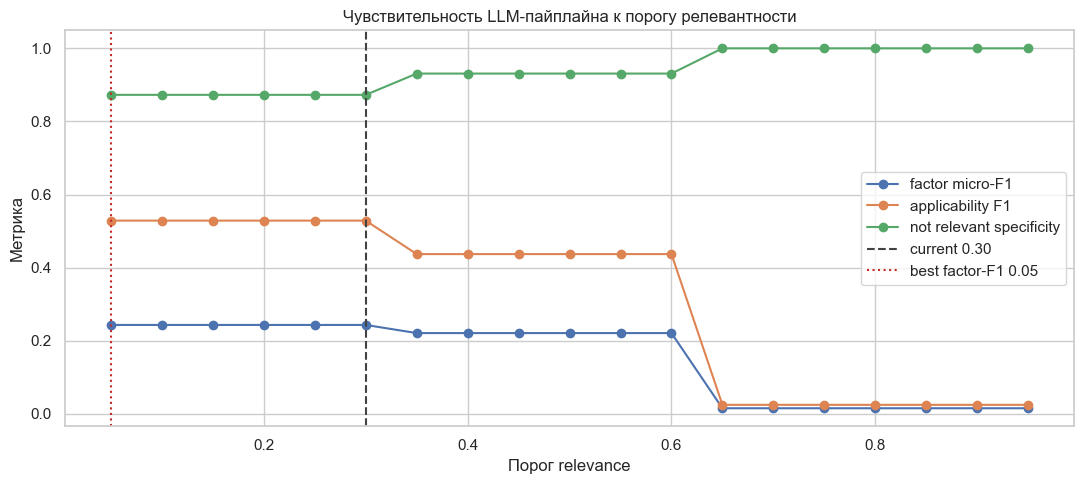

,threshold,factor_micro_precision,factor_micro_recall,factor_micro_f1,factor_macro_f1,applicability_precision,applicability_recall,applicability_specificity,applicability_f1,predicted_relevant_pairs
0,0.05,0.4702,0.1639,0.2431,0.0956,0.8864,0.3766,0.8727,0.5286,319
1,0.10,0.4702,0.1639,0.2431,0.0956,0.8864,0.3766,0.8727,0.5286,319
2,0.15,0.4702,0.1639,0.2431,0.0956,0.8864,0.3766,0.8727,0.5286,319
3,0.20,0.4702,0.1639,0.2431,0.0956,0.8864,0.3766,0.8727,0.5286,319
4,0.25,0.4702,0.1639,0.2431,0.0956,0.8864,0.3766,0.8727,0.5286,319
5,0.30,0.4702,0.1639,0.2431,0.0956,0.8864,0.3766,0.8727,0.5286,319
6,0.35,0.5404,0.1388,0.2209,0.0935,0.9163,0.2869,0.9309,0.4370,235
7,0.40,0.5404,0.1388,0.2209,0.0935,0.9163,0.2869,0.9309,0.4370,235
8,0.45,0.5404,0.1388,0.2209,0.0935,0.9163,0.2869,0.9309,0.4370,235
9,0.50,0.5404,0.1388,0.2209,0.0935,0.9163,0.2869,0.9309,0.4370,235


In [6]:
def regression_metrics(y_true, y_pred, name: str) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return {
        "target": name,
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": math.sqrt(mean_squared_error(y_true, y_pred)),
        "r2": r2_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else np.nan,
        "pearson": pd.Series(y_true).corr(pd.Series(y_pred), method="pearson"),
        "spearman": pd.Series(y_true).corr(pd.Series(y_pred), method="spearman"),
    }

regression_table = pd.DataFrame(
    [
        regression_metrics(manual_factor_pred["manual_sentiment_num"], manual_factor_pred["sentiment_score"], "sentiment_score_on_true_factor"),
        regression_metrics(manual_factor_pred["manual_relevance_num"], manual_factor_pred["relevance"], "relevance_on_true_factor"),
        regression_metrics(manual_factor_pred["manual_pressure_num"], manual_factor_pred["pressure"], "pressure_on_true_factor"),
    ]
)
display(regression_table.round(4))

thresholds = np.round(np.arange(0.05, 0.96, 0.05), 2)
sweep_rows = []
for threshold in thresholds:
    pred_threshold = score_matrix.ge(threshold) & (
        sentiment_matrix.abs().ge(DEFAULT_LLM_SIGNAL_THRESHOLD)
        | pred_long.pivot(index="dataset_row_id", columns="factor_key", values="pressure").reindex(index=df["dataset_row_id"], columns=factor_keys).fillna(0.0).ge(DEFAULT_LLM_SIGNAL_THRESHOLD)
        | label_matrix.ne("neutral")
    )
    y_pred_factor = pred_threshold.astype(int).to_numpy()
    micro_precision, micro_recall, micro_f1, _ = precision_recall_fscore_support(y_factor_true, y_pred_factor, average="micro", zero_division=0)
    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(y_factor_true, y_pred_factor, average="macro", zero_division=0)
    y_pred_any = pred_threshold.any(axis=1).astype(int)
    app = binary_metrics(y_app_true, y_pred_any)
    sweep_rows.append(
        {
            "threshold": threshold,
            "factor_micro_precision": micro_precision,
            "factor_micro_recall": micro_recall,
            "factor_micro_f1": micro_f1,
            "factor_macro_f1": macro_f1,
            "applicability_precision": app["precision"],
            "applicability_recall": app["recall_relevant"],
            "applicability_specificity": app["specificity_not_relevant"],
            "applicability_f1": app["f1"],
            "predicted_relevant_pairs": int(y_pred_factor.sum()),
        }
    )
threshold_sweep = pd.DataFrame(sweep_rows)
best_threshold = threshold_sweep.sort_values("factor_micro_f1", ascending=False).iloc[0]
display(best_threshold.to_frame("value"))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(threshold_sweep["threshold"], threshold_sweep["factor_micro_f1"], marker="o", label="factor micro-F1")
ax.plot(threshold_sweep["threshold"], threshold_sweep["applicability_f1"], marker="o", label="applicability F1")
ax.plot(threshold_sweep["threshold"], threshold_sweep["applicability_specificity"], marker="o", label="not relevant specificity")
ax.axvline(DEFAULT_LLM_RELEVANCE_THRESHOLD, color="#424242", linestyle="--", label=f"current {DEFAULT_LLM_RELEVANCE_THRESHOLD:.2f}")
ax.axvline(best_threshold["threshold"], color="#c62828", linestyle=":", label=f"best factor-F1 {best_threshold['threshold']:.2f}")
ax.set_xlabel("Порог relevance")
ax.set_ylabel("Метрика")
ax.set_title("Чувствительность LLM-пайплайна к порогу релевантности")
ax.legend()
plt.tight_layout()
plt.show()

display(threshold_sweep.round(4))

## 6. Error analysis

In [7]:
false_positive = eval_df[(~eval_df["manual_applicable_bool"]) & eval_df["pred_any_relevant"]].copy()
false_negative = eval_df[(eval_df["manual_applicable_bool"]) & (~eval_df["pred_any_relevant"])].copy()
wrong_primary = applicable_eval[~applicable_eval["manual_in_top1"]].copy()
factor_recall_table = (
    manual_factor_pred.assign(true_factor_returned=manual_factor_pred["is_relevant"].astype(bool))
    .groupby("manual_primary_factor")
    .agg(
        manual_count=("dataset_row_id", "count"),
        true_factor_recalled=("true_factor_returned", "sum"),
    )
    .assign(recall=lambda frame: frame["true_factor_recalled"] / frame["manual_count"])
    .sort_values("manual_count", ascending=False)
)

display(Markdown(f'''
**False positives**: {len(false_positive)} из {(~eval_df["manual_applicable_bool"]).sum()} ручных `not_relevant`.

**False negatives**: {len(false_negative)} из {eval_df["manual_applicable_bool"].sum()} ручных relevant.

**Wrong primary factor among relevant**: {len(wrong_primary)} из {len(applicable_eval)}.
'''))
display(factor_recall_table.head(24).round(3))

if len(false_positive):
    fp_factors = false_positive["pred_relevant_factors"].explode().value_counts().head(15)
    display(fp_factors.rename("false_positive_factor_hits").to_frame())
    display(false_positive[[COL["title"], "manual_primary_factor", "pred_relevant_factors", "pred_primary_relevance", "pred_primary_sentiment_label"]].head(12))

if len(false_negative):
    display(false_negative["manual_primary_factor"].value_counts().head(15).rename("false_negative_manual_factor").to_frame())
    display(false_negative[[COL["title"], "manual_primary_factor", "manual_signal_norm", "manual_relevance_num", "manual_pressure_num"]].head(12))

if len(wrong_primary):
    display(
        wrong_primary[[COL["title"], "manual_primary_factor", "pred_primary_factor_key", "pred_relevant_factors", "manual_signal_norm", "pred_primary_sentiment_label"]]
        .head(16)
    )


**False positives**: 35 из 275 ручных `not_relevant`.

**False negatives**: 452 из 725 ручных relevant.

**Wrong primary factor among relevant**: 601 из 725.


,manual_count,true_factor_recalled,recall
manual_primary_factor,,,
crime_count,201,28,0.139
industrial_production_index,176,36,0.205
enterprises_count,133,17,0.128
consumer_price_index,54,22,0.407
air_pollution,28,2,0.071
mortality_rate,28,2,0.071
life_expectancy,26,1,0.038
international_inflow,25,10,0.400
housing_area_per_capita,15,1,0.067


,false_positive_factor_hits
pred_relevant_factors,
international_inflow,17
industrial_production_index,8
consumer_price_index,5
enterprises_count,2
internal_departures,1
international_outflow,1
per_capita_income,1
hospitals,1


,Заголовок новости,manual_primary_factor,pred_relevant_factors,pred_primary_relevance,pred_primary_sentiment_label
dataset_row_id,,,,,
2,Мозамбик пригласил российские компании добывать газ в стране,not_relevant,[international_inflow],0.6,positive
6,Консерватор Каст одержал победу на выборах президента Чили,not_relevant,[international_inflow],0.6,positive
38,Рынок акций РФ в четверг сбавил темпы снижения благодаря заявлениям Путина,not_relevant,[international_inflow],0.3,positive
49,Путин поздравил Лукашенко с днем рождения,not_relevant,[international_inflow],0.3,positive
74,Дмитриев анонсировал новые российско-американские контакты на следующей неделе,not_relevant,[international_inflow],0.6,positive
112,Трамп заявил об успехах своей экономической политики,not_relevant,[consumer_price_index],0.6,positive
115,Лавров 17 июня встретится в Москве с главой МИД Индонезии,not_relevant,[international_inflow],0.6,positive
132,"Акции ""М.Видео"" заметно дорожают второй день подряд на слухах о продаже торговой сети",not_relevant,"[enterprises_count, industrial_production_index]",0.3,positive
188,General Motors запускает обратный выкуп акций на $6 млрд,not_relevant,[enterprises_count],0.6,positive


,false_negative_manual_factor
manual_primary_factor,
crime_count,150
industrial_production_index,105
enterprises_count,72
consumer_price_index,27
air_pollution,22
mortality_rate,20
life_expectancy,16
international_inflow,12
housing_area_per_capita,12


,Заголовок новости,manual_primary_factor,manual_signal_norm,manual_relevance_num,manual_pressure_num
dataset_row_id,,,,,
1,Путин поручил разработать план подъема двух затонувших в Черном море танкеров,air_pollution,negative,0.90,0.85
7,Женщина погибла в результате атаки беспилотников ВСУ на населенный пункт Вахрушево в ЛНР,crime_count,negative,0.95,0.95
15,Байден заблокировал сделку между US Steel и Nippon Steel,industrial_production_index,negative,0.45,0.20
23,Сорвалась очередная ротация экспертов МАГАТЭ на Запорожской АЭС,air_pollution,negative,0.55,0.45
26,В МИД РФ связали атаку беспилотников с визитом генсека ОБСЕ в Москву,crime_count,negative,0.85,0.75
30,"Что произошло за день: пятница, 3 октября",consumer_price_index,negative,0.65,0.45
31,"Что произошло за день: вторник, 17 июня",crime_count,negative,0.70,0.70
32,Армия обороны Израиля сообщила о новой ракетной атаке Ирана,crime_count,negative,0.85,0.80
33,"Oersted спишет $1,7 млрд из-за роста ставок, обесценения земли и проблем в ветроэнергетике в США",industrial_production_index,negative,0.50,0.25


,Заголовок новости,manual_primary_factor,pred_primary_factor_key,pred_relevant_factors,manual_signal_norm,pred_primary_sentiment_label
dataset_row_id,,,,,,
1,Путин поручил разработать план подъема двух затонувших в Черном море танкеров,air_pollution,not_relevant,[],negative,neutral
7,Женщина погибла в результате атаки беспилотников ВСУ на населенный пункт Вахрушево в ЛНР,crime_count,not_relevant,[],negative,neutral
10,"""Москвич"" в 2025 году планирует начать сборку новой модели на базе китайского SAIC",industrial_production_index,enterprises_count,[enterprises_count],positive,positive
13,Колокольцев указал на ухудшение обстановки в мире на фоне смягчения наркоконтроля в ряде стран,crime_count,international_inflow,[international_inflow],negative,negative
15,Байден заблокировал сделку между US Steel и Nippon Steel,industrial_production_index,not_relevant,[],negative,neutral
16,Состояние пострадавших при ЧП в Курской области сотрудников РЖД удовлетворительное,life_expectancy,hospitals,[hospitals],positive,positive
17,Работающие россияне смогут получить налоговый вычет за оплату спортивных занятий родителям,per_capita_income,child_living_wage,[child_living_wage],positive,positive
21,В Херсонской области в результате обстрела ранены водитель и врач скорой помощи,crime_count,hospitals,[hospitals],negative,negative
23,Сорвалась очередная ротация экспертов МАГАТЭ на Запорожской АЭС,air_pollution,not_relevant,[],negative,neutral


## 7. Сравнение агрегатов dashboard-графиков

C:\Users\whynot\AppData\Local\Temp\ipykernel_87788\790810461.py:28: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  manual_long["is_relevant"] = manual_long["is_relevant"].fillna(False).astype(bool)


,target,mae,rmse,r2,pearson,spearman
0,daily_average_sentiment,0.0223,0.0294,0.1449,0.4073,0.4023
1,daily_risk_index,0.0183,0.0267,-0.4040,0.3667,0.3826
2,factor_date_average_sentiment,0.0453,0.2060,-0.0337,0.1944,0.1895
3,factor_date_relevant_news_count,0.0579,0.2737,0.0477,0.3571,0.3247


,manual_relevant_total,pred_relevant_total,sentiment_mae,relevant_count_mae
factor_key,,,,
crime_count,201,35,0.381,0.504
industrial_production_index,176,76,0.344,0.442
enterprises_count,133,28,0.237,0.326
consumer_price_index,54,45,0.136,0.133
air_pollution,28,2,0.071,0.074
mortality_rate,28,3,0.068,0.076
life_expectancy,26,2,0.061,0.074
international_inflow,25,72,0.133,0.190
housing_area_per_capita,15,1,0.038,0.040


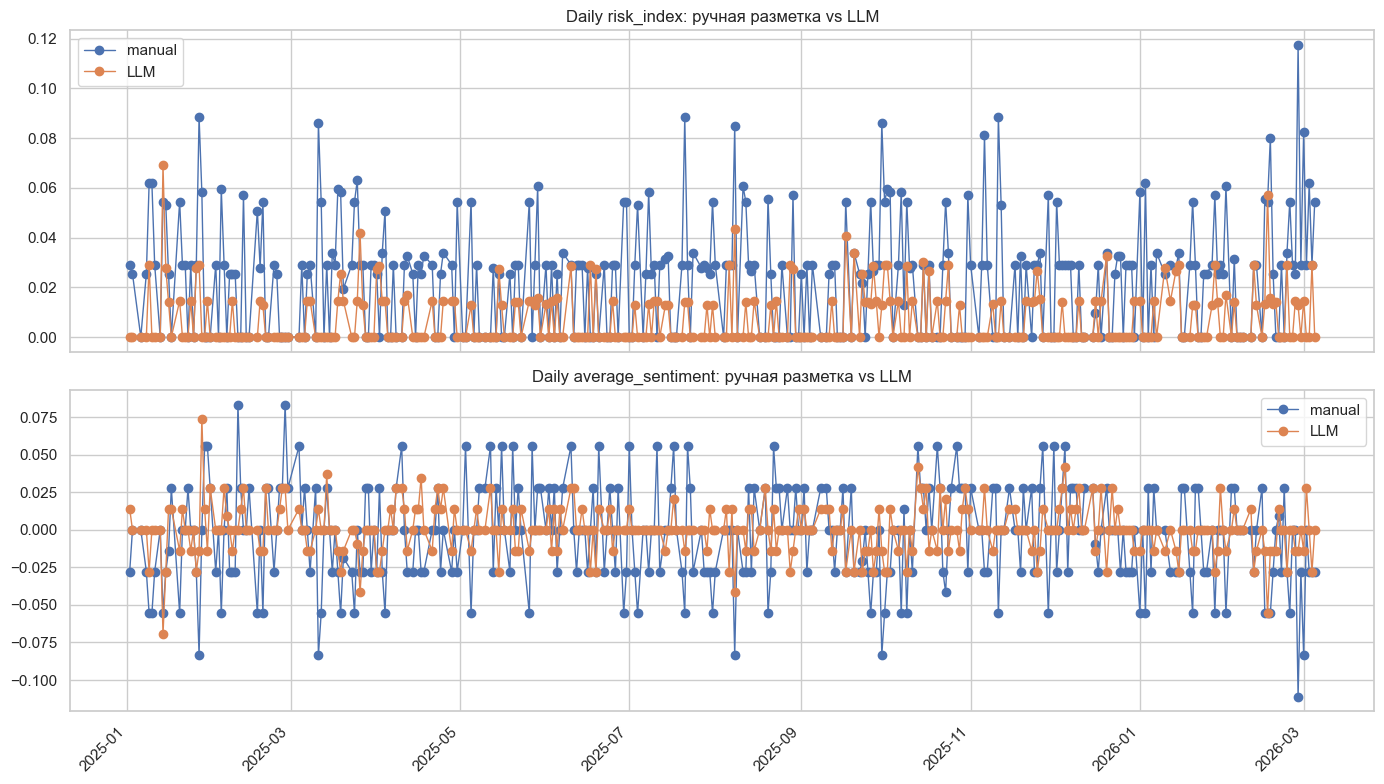

In [8]:
dates = sorted(df["published_date"].dropna().unique())
date_factor_index = pd.MultiIndex.from_product([dates, factor_keys], names=["published_date", "factor_key"])

manual_main_long = df.loc[
    df["manual_applicable_bool"] & df["manual_primary_factor"].isin(factor_keys),
    ["dataset_row_id", "published_date", "manual_primary_factor", "manual_sentiment_num", "manual_signal_norm"],
].rename(
    columns={
        "manual_primary_factor": "factor_key",
        "manual_sentiment_num": "sentiment_score",
        "manual_signal_norm": "sentiment_label",
    }
)
manual_main_long["is_relevant"] = True

manual_long = (
    pd.MultiIndex.from_product([df["dataset_row_id"], factor_keys], names=["dataset_row_id", "factor_key"])
    .to_frame(index=False)
    .merge(df.set_index("dataset_row_id")[["published_date"]], left_on="dataset_row_id", right_index=True, how="left")
    .merge(
        manual_main_long[["dataset_row_id", "factor_key", "sentiment_score", "sentiment_label", "is_relevant"]],
        on=["dataset_row_id", "factor_key"],
        how="left",
    )
)
manual_long["sentiment_score"] = manual_long["sentiment_score"].fillna(0.0)
manual_long["sentiment_label"] = manual_long["sentiment_label"].fillna("neutral")
manual_long["is_relevant"] = manual_long["is_relevant"].fillna(False).astype(bool)

predicted_long = pred_long.merge(
    df.set_index("dataset_row_id")[["published_date"]],
    left_on="dataset_row_id",
    right_index=True,
    how="left",
)

def aggregate_like_dashboard(long_df: pd.DataFrame, score_col: str = "sentiment_score") -> tuple[pd.DataFrame, pd.DataFrame]:
    total_news_by_date = df.groupby("published_date")["dataset_row_id"].nunique().rename("news_count")
    relevant = long_df[long_df["is_relevant"]].copy()
    avg_sentiment = relevant.groupby(["published_date", "factor_key"])[score_col].mean().rename("average_sentiment")
    relevant_counts = relevant.groupby(["published_date", "factor_key"])["dataset_row_id"].nunique().rename("relevant_news_count")
    positive_hits = relevant[relevant["sentiment_label"] == "positive"].groupby(["published_date", "factor_key"]).size().rename("positive_hits")
    negative_hits = relevant[relevant["sentiment_label"] == "negative"].groupby(["published_date", "factor_key"]).size().rename("negative_hits")
    neutral_hits = long_df[long_df["sentiment_label"] == "neutral"].groupby(["published_date", "factor_key"]).size().rename("neutral_hits")

    factor_daily = pd.DataFrame(index=date_factor_index).join(
        [avg_sentiment, relevant_counts, positive_hits, negative_hits, neutral_hits]
    ).fillna(0.0).reset_index()
    for column in ["relevant_news_count", "positive_hits", "negative_hits", "neutral_hits"]:
        factor_daily[column] = factor_daily[column].astype(int)
    factor_daily["weight"] = factor_daily["factor_key"].map(factor_weights).astype(float)

    daily_records = []
    total_weight = factor_df["weight"].sum()
    for day, items in factor_daily.groupby("published_date"):
        average_sentiment = items["average_sentiment"].mean()
        risk_index = (np.maximum(-items["average_sentiment"], 0.0) * items["weight"]).sum() / total_weight
        daily_records.append(
            {
                "published_date": day,
                "average_sentiment": average_sentiment,
                "risk_index": risk_index,
                "news_count": int(total_news_by_date.get(day, 0)),
                "factor_count": len(items),
            }
        )
    daily = pd.DataFrame(daily_records).sort_values("published_date")
    daily["delta_from_previous"] = daily["average_sentiment"].diff().fillna(0.0)
    factor_daily["delta_from_previous"] = factor_daily.sort_values(["factor_key", "published_date"]).groupby("factor_key")["average_sentiment"].diff().fillna(0.0)
    return daily, factor_daily

manual_daily, manual_factor_daily = aggregate_like_dashboard(manual_long)
pred_daily, pred_factor_daily = aggregate_like_dashboard(predicted_long)

daily_compare = manual_daily.merge(pred_daily, on="published_date", suffixes=("_manual", "_pred"))
factor_compare = manual_factor_daily.merge(pred_factor_daily, on=["published_date", "factor_key"], suffixes=("_manual", "_pred"))

graph_metrics = pd.DataFrame(
    [
        regression_metrics(daily_compare["average_sentiment_manual"], daily_compare["average_sentiment_pred"], "daily_average_sentiment"),
        regression_metrics(daily_compare["risk_index_manual"], daily_compare["risk_index_pred"], "daily_risk_index"),
        regression_metrics(factor_compare["average_sentiment_manual"], factor_compare["average_sentiment_pred"], "factor_date_average_sentiment"),
        regression_metrics(factor_compare["relevant_news_count_manual"], factor_compare["relevant_news_count_pred"], "factor_date_relevant_news_count"),
    ]
)
display(graph_metrics.round(4))

factor_error = (
    factor_compare.assign(
        abs_sentiment_error=lambda x: (x["average_sentiment_manual"] - x["average_sentiment_pred"]).abs(),
        abs_relevant_count_error=lambda x: (x["relevant_news_count_manual"] - x["relevant_news_count_pred"]).abs(),
    )
    .groupby("factor_key")
    .agg(
        manual_relevant_total=("relevant_news_count_manual", "sum"),
        pred_relevant_total=("relevant_news_count_pred", "sum"),
        sentiment_mae=("abs_sentiment_error", "mean"),
        relevant_count_mae=("abs_relevant_count_error", "mean"),
    )
    .sort_values(["manual_relevant_total", "sentiment_mae"], ascending=[False, False])
)
display(factor_error.head(20).round(3))

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
axes[0].plot(daily_compare["published_date"], daily_compare["risk_index_manual"], label="manual", marker="o", linewidth=1)
axes[0].plot(daily_compare["published_date"], daily_compare["risk_index_pred"], label="LLM", marker="o", linewidth=1)
axes[0].set_title("Daily risk_index: ручная разметка vs LLM")
axes[0].legend()

axes[1].plot(daily_compare["published_date"], daily_compare["average_sentiment_manual"], label="manual", marker="o", linewidth=1)
axes[1].plot(daily_compare["published_date"], daily_compare["average_sentiment_pred"], label="LLM", marker="o", linewidth=1)
axes[1].set_title("Daily average_sentiment: ручная разметка vs LLM")
axes[1].legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 8. LLM vs BERT baseline

In [9]:
bert_summary_path = OUTPUT_DIR / "manual_dataset_eval_summary.json"
bert_summary = json.loads(bert_summary_path.read_text(encoding="utf-8")) if bert_summary_path.exists() else {}

llm_summary_metrics = {
    "dataset_rows": int(len(df)),
    "manual_applicable_rows": int(df["manual_applicable_bool"].sum()),
    "manual_not_relevant_rows": int((~df["manual_applicable_bool"]).sum()),
    "model": llm_settings.model,
    "classification_prompt_version": llm_settings.classification_prompt_version,
    "factor_catalog_version": FACTOR_CATALOG_VERSION,
    "eval_batch_size": EVAL_LLM_BATCH_SIZE,
    "default_threshold": DEFAULT_LLM_RELEVANCE_THRESHOLD,
    "best_threshold_by_factor_micro_f1": float(best_threshold["threshold"]),
    "applicability_accuracy": float(applicability_metrics.loc[0, "accuracy"]),
    "applicability_balanced_accuracy": float(applicability_metrics.loc[0, "balanced_accuracy"]),
    "applicability_precision": float(applicability_metrics.loc[0, "precision"]),
    "applicability_recall_relevant": float(applicability_metrics.loc[0, "recall_relevant"]),
    "applicability_specificity_not_relevant": float(applicability_metrics.loc[0, "specificity_not_relevant"]),
    "applicability_f1": float(applicability_metrics.loc[0, "f1"]),
    "applicability_mcc": float(applicability_metrics.loc[0, "mcc"]),
    "factor_micro_f1": float(factor_metrics.loc[factor_metrics["average"] == "micro", "f1"].iloc[0]),
    "factor_macro_f1": float(factor_metrics.loc[factor_metrics["average"] == "macro", "f1"].iloc[0]),
    "primary_factor_top1_accuracy": float(primary_factor_metrics.loc[primary_factor_metrics["metric"] == "primary_factor_top1_accuracy", "value"].iloc[0]),
    "primary_factor_top3_hit_rate": float(primary_factor_metrics.loc[primary_factor_metrics["metric"] == "primary_factor_top3_hit_rate", "value"].iloc[0]),
    "primary_factor_top5_hit_rate": float(primary_factor_metrics.loc[primary_factor_metrics["metric"] == "primary_factor_top5_hit_rate", "value"].iloc[0]),
    "signal_accuracy_on_true_factor": float(signal_accuracy),
    "signal_macro_f1_on_true_factor": float(signal_macro_f1),
    "true_factor_recall": float(true_factor_recall),
    "signal_accuracy_when_true_factor_returned": float(conditional_signal_accuracy),
    "signal_macro_f1_when_true_factor_returned": float(conditional_signal_macro_f1),
    "daily_risk_index_rmse": float(graph_metrics.loc[graph_metrics["target"] == "daily_risk_index", "rmse"].iloc[0]),
    "daily_average_sentiment_rmse": float(graph_metrics.loc[graph_metrics["target"] == "daily_average_sentiment", "rmse"].iloc[0]),
}

comparison_rows = []
metric_map = [
    ("Applicability F1", "applicability_f1_at_default", "applicability_f1"),
    ("Factor micro-F1", "factor_micro_f1_at_default", "factor_micro_f1"),
    ("Primary factor top-1", "primary_factor_top1_accuracy", "primary_factor_top1_accuracy"),
    ("Primary factor top-3", "primary_factor_top3_hit_rate", "primary_factor_top3_hit_rate"),
    ("Signal accuracy on true factor", "signal_accuracy_on_true_factor", "signal_accuracy_on_true_factor"),
    ("Daily risk_index RMSE", "daily_risk_index_rmse", "daily_risk_index_rmse"),
    ("Daily average_sentiment RMSE", "daily_average_sentiment_rmse", "daily_average_sentiment_rmse"),
]
for label, bert_key, llm_key in metric_map:
    comparison_rows.append(
        {
            "metric": label,
            "bert_baseline": bert_summary.get(bert_key),
            "llm_pipeline": llm_summary_metrics.get(llm_key),
            "delta_llm_minus_bert": None
            if bert_summary.get(bert_key) is None
            else llm_summary_metrics.get(llm_key) - bert_summary.get(bert_key),
        }
    )
comparison_table = pd.DataFrame(comparison_rows)
display(comparison_table.round(4))

,metric,bert_baseline,llm_pipeline,delta_llm_minus_bert
0,Applicability F1,0.8406,0.5286,-0.3120
1,Factor micro-F1,0.0656,0.2431,0.1775
2,Primary factor top-1,0.0814,0.1710,0.0897
3,Primary factor top-3,0.2359,0.2731,0.0372
4,Signal accuracy on true factor,0.3959,0.1669,-0.2290
5,Daily risk_index RMSE,0.1284,0.0267,-0.1017
6,Daily average_sentiment RMSE,0.1158,0.0294,-0.0864


## 9. Сохранение артефактов и интерпретация

In [10]:
output_paths = {
    "predictions": final_predictions_path,
    "raw_jsonl": raw_jsonl_path,
    "errors": errors_path,
    "metrics_summary": OUTPUT_DIR / "manual_dataset_llm_metrics_summary.csv",
    "factor_metrics": OUTPUT_DIR / "manual_dataset_llm_multilabel_factor_metrics.csv",
    "threshold_sweep": OUTPUT_DIR / "manual_dataset_llm_threshold_sweep.csv",
    "regression_metrics": OUTPUT_DIR / "manual_dataset_llm_regression_metrics.csv",
    "graph_metrics": OUTPUT_DIR / "manual_dataset_llm_graph_metrics.csv",
    "daily_compare": OUTPUT_DIR / "manual_dataset_llm_daily_aggregate_comparison.csv",
    "factor_error": OUTPUT_DIR / "manual_dataset_llm_factor_aggregate_errors.csv",
    "eval_rows": OUTPUT_DIR / "manual_dataset_llm_eval_rows.csv",
    "comparison_with_bert": OUTPUT_DIR / "manual_dataset_llm_vs_bert.csv",
    "summary_json": OUTPUT_DIR / "manual_dataset_llm_eval_summary.json",
}

metrics_summary = pd.concat(
    [
        applicability_metrics.assign(section="applicability"),
        primary_factor_metrics.rename(columns={"metric": "metric_group"}).assign(section="primary_factor"),
        signal_metrics.rename(columns={"metric": "metric_group"}).assign(section="signal"),
    ],
    ignore_index=True,
    sort=False,
)
metrics_summary.to_csv(output_paths["metrics_summary"], index=False, encoding="utf-8")
factor_metrics.to_csv(output_paths["factor_metrics"], index=False, encoding="utf-8")
threshold_sweep.to_csv(output_paths["threshold_sweep"], index=False, encoding="utf-8")
regression_table.to_csv(output_paths["regression_metrics"], index=False, encoding="utf-8")
graph_metrics.to_csv(output_paths["graph_metrics"], index=False, encoding="utf-8")
daily_compare.to_csv(output_paths["daily_compare"], index=False, encoding="utf-8")
factor_error.to_csv(output_paths["factor_error"], encoding="utf-8")
eval_df.reset_index().to_csv(output_paths["eval_rows"], index=False, encoding="utf-8")
comparison_table.to_csv(output_paths["comparison_with_bert"], index=False, encoding="utf-8")
output_paths["summary_json"].write_text(json.dumps({**llm_summary_metrics, "output_paths": {k: str(v) for k, v in output_paths.items()}}, ensure_ascii=False, indent=2), encoding="utf-8")

def verdict(value, good, warn=None, higher_is_better=True):
    if value is None or pd.isna(value):
        return "нет данных"
    if higher_is_better:
        if value >= good:
            return "сильно"
        if warn is not None and value >= warn:
            return "средне"
        return "слабо"
    if value <= good:
        return "сильно"
    if warn is not None and value <= warn:
        return "средне"
    return "слабо"

interpretation = f'''
## Краткий вывод

LLM-пайплайн проверен на {len(df)} ручных новостях.

- `not_relevant specificity`: {llm_summary_metrics['applicability_specificity_not_relevant']:.3f} ({verdict(llm_summary_metrics['applicability_specificity_not_relevant'], 0.75, 0.55)})
- `relevant recall`: {llm_summary_metrics['applicability_recall_relevant']:.3f}
- `factor micro-F1`: {llm_summary_metrics['factor_micro_f1']:.3f} ({verdict(llm_summary_metrics['factor_micro_f1'], 0.60, 0.35)})
- `primary factor top-1`: {llm_summary_metrics['primary_factor_top1_accuracy']:.3f}
- `primary factor top-3`: {llm_summary_metrics['primary_factor_top3_hit_rate']:.3f}
- `signal accuracy on true factor`: {llm_summary_metrics['signal_accuracy_on_true_factor']:.3f}
- `signal accuracy when true factor returned`: {llm_summary_metrics['signal_accuracy_when_true_factor_returned']:.3f}
- `daily risk_index RMSE`: {llm_summary_metrics['daily_risk_index_rmse']:.3f} ({verdict(llm_summary_metrics['daily_risk_index_rmse'], 0.05, 0.10, higher_is_better=False)})

Главный практический смысл:
если specificity по `not_relevant` низкая, графики будут зашумлены ложными факторами;
если factor-F1 низкий, модель может видеть "социальный сигнал", но класть его не в тот фактор;
если общий signal accuracy низкий, но conditional signal accuracy высокий, то главная проблема не в тональности,
а в gate/recall правильного фактора.
'''
display(Markdown(interpretation))

print("Saved artifacts:")
for key, value in output_paths.items():
    print(f"- {key}: {value}")


## Краткий вывод

LLM-пайплайн проверен на 1000 ручных новостях.

- `not_relevant specificity`: 0.873 (сильно)
- `relevant recall`: 0.377
- `factor micro-F1`: 0.243 (слабо)
- `primary factor top-1`: 0.171
- `primary factor top-3`: 0.273
- `signal accuracy on true factor`: 0.167
- `signal accuracy when true factor returned`: 0.871
- `daily risk_index RMSE`: 0.027 (сильно)

Главный практический смысл:
если specificity по `not_relevant` низкая, графики будут зашумлены ложными факторами;
если factor-F1 низкий, модель может видеть "социальный сигнал", но класть его не в тот фактор;
если общий signal accuracy низкий, но conditional signal accuracy высокий, то главная проблема не в тональности,
а в gate/recall правильного фактора.


Saved artifacts:
- predictions: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\manual_dataset_llm_predictions_gemma4-e2b_social-risk-classification-v1_5df03950348d_033f6fd8763b.csv
- raw_jsonl: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\manual_dataset_llm_predictions_gemma4-e2b_social-risk-classification-v1_5df03950348d_033f6fd8763b.raw.jsonl
- errors: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\manual_dataset_llm_predictions_gemma4-e2b_social-risk-classification-v1_5df03950348d_033f6fd8763b.errors.csv
- metrics_summary: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\manual_dataset_llm_metrics_summary.csv
- factor_metrics: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\manual_dataset_llm_multilabel_factor_metrics.csv
- threshold_sweep: C:\Users\whynot\VSCodeProjects\news-zero-shot\analysis_outputs\manual_dataset_llm_threshold_sweep.csv
- regression_metrics: C:\Users\whynot\VSCodeProjects\news-zero-sh